In [1]:
import forte2
import mutual_correlation_energy_mod_fast as mcmod
from plot_correlation_energy import mutual_correlation_plot

In [2]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.000 1.740
"""
system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0.0),active_orbitals=[0,1])(rhf) #2 electrons in 2 spin-orbitals 
ci.run()


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
Parsed 2 atoms with basis set of 10 functions.
  Max eigenvalue: 2.268e+00
  Min eigenvalue: 1.969e-01
  Condition number: 1.152e+01
  Inverse condition number: 8.683e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 10
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.969e-01
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 10
Number of orthogonalized basis functions: 10
Number of auxiliary basis functions: 60
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 10
Number of auxiliary basis functions:

CI(states=State(multiplicity=1, ms=0.0, nel=2, system=System(atoms=[[1, array([0., 0., 0.])], [1, array([0.        , 0.        , 3.28812346])]], basis_set=<Basis 'cc-pVDZ' with 10 basis functions>, auxiliary_basis_set=<Basis 'cc-pVTZ-JKFIT' with 60 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=1, nb=1, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=10, active_orbitals=[[0, 1]], core_orbitals=[], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=[0, 1], frozen_virtual_orbitals=None, die_if_not_converged=True, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=3, final_orbital='original', do_transition_dipole=False)

In [3]:
import numpy as np

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci, nat_orbs=True, nocc=2)
print(MCEmat.mutual_correlation_matrix_summary())

print(MCEmat.get_M2_matrix())

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.1449075869

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       0        1    -0.2342664562
[[ 0.         -0.23426646]
 [-0.23426646  0.        ]]


In [4]:
print("aa, ab, ba, bb cumulants:")
print(mcmod._spin_dependent_2cumulants(ci)[2])

print("spin-summed 2-cumulant terms:")
c_tensor = mcmod._spin_summed_2cumulant(ci)
for i in range(0,2):
    for j in range(0,2):
        for k in range(0,2):
            for l in range(0,2):
                if abs(c_tensor[i][j][k][l]) > 1e-15:
                    print(f"p={i}, q={j}, r={k}, s={l} : {c_tensor[i][j][k][l]}")

aa, ab, ba, bb cumulants:
[[[[ 0.          0.        ]
   [ 0.          0.        ]]

  [[ 0.         -0.10717972]
   [ 0.10717972  0.        ]]]


 [[[ 0.          0.10717972]
   [-0.10717972  0.        ]]

  [[ 0.          0.        ]
   [ 0.          0.        ]]]]
spin-summed 2-cumulant terms:
p=0, q=0, r=0, s=0 : 0.21435943277788394
p=0, q=0, r=1, s=1 : -0.6547662678817295
p=0, q=1, r=0, s=1 : -0.4287188655557687
p=0, q=1, r=1, s=0 : 0.21435943277788436
p=1, q=0, r=0, s=1 : 0.21435943277788436
p=1, q=0, r=1, s=0 : -0.4287188655557687
p=1, q=1, r=0, s=0 : -0.6547662678817295
p=1, q=1, r=1, s=1 : 0.21435943277788433


In [5]:
c1 = 0.936972
c2 = -0.349406

print(2*(c1**2 - c1**4)) #diagonal 1,2
print(2*(c2**2 - c2**4)) #diagonal 3,4
print(2*(c1*c2)) #off diagonal 
print(-4*(c1**2)*(c2**2))
print(2*(c1**2)*(c2**2))

0.21435819454370408
0.21435982958966782
-0.654767277264
-0.4287201873757118
0.2143600936878559


In [6]:
ints = forte2.jkbuilder.RestrictedMOIntegrals(
        system=ci.system,
        C=ci.C[0],
        orbitals=ci.active_indices
    )
V = ints.V
print("Two electron integrals")
for i in range(0,2):
    for j in range(0,2):
        for k in range(0,2):
            for l in range(0,2):
                if abs(c_tensor[i][j][k][l]) > 1e-15:
                    print(f"p={i}, q={j}, r={k}, s={l} : {V[i][j][k][l]}")

print("")
print("2-Frag orbital correlation")
for i in range(0,2):
    for j in range(0,2):
        for k in range(0,2):
            for l in range(0,2):
                if abs(c_tensor[i][j][k][l]) > 1e-15:
                    print(f"p={i}, q={j}, r={k}, s={l} : {c_tensor[i][j][k][l]* V[i][j][k][l]}")

Two electron integrals
p=0, q=0, r=0, s=0 : 0.443161485663205
p=0, q=0, r=1, s=1 : 0.1396913735198481
p=0, q=1, r=0, s=1 : 0.402934030506148
p=0, q=1, r=1, s=0 : 0.13969137351984812
p=1, q=0, r=0, s=1 : 0.1396913735198481
p=1, q=0, r=1, s=0 : 0.40293403050614796
p=1, q=1, r=0, s=0 : 0.1396913735198481
p=1, q=1, r=1, s=1 : 0.39056780787414763

2-Frag orbital correlation
p=0, q=0, r=0, s=0 : 0.09499584469576897
p=0, q=0, r=1, s=1 : -0.09146519929486359
p=0, q=1, r=0, s=1 : -0.1727454204524093
p=0, q=1, r=1, s=0 : 0.029944163591678216
p=1, q=0, r=0, s=1 : 0.029944163591678213
p=1, q=0, r=1, s=0 : -0.17274542045240926
p=1, q=1, r=0, s=0 : -0.09146519929486359
p=1, q=1, r=1, s=1 : 0.08372189375720399



Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 40 x 57 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [0, 1]



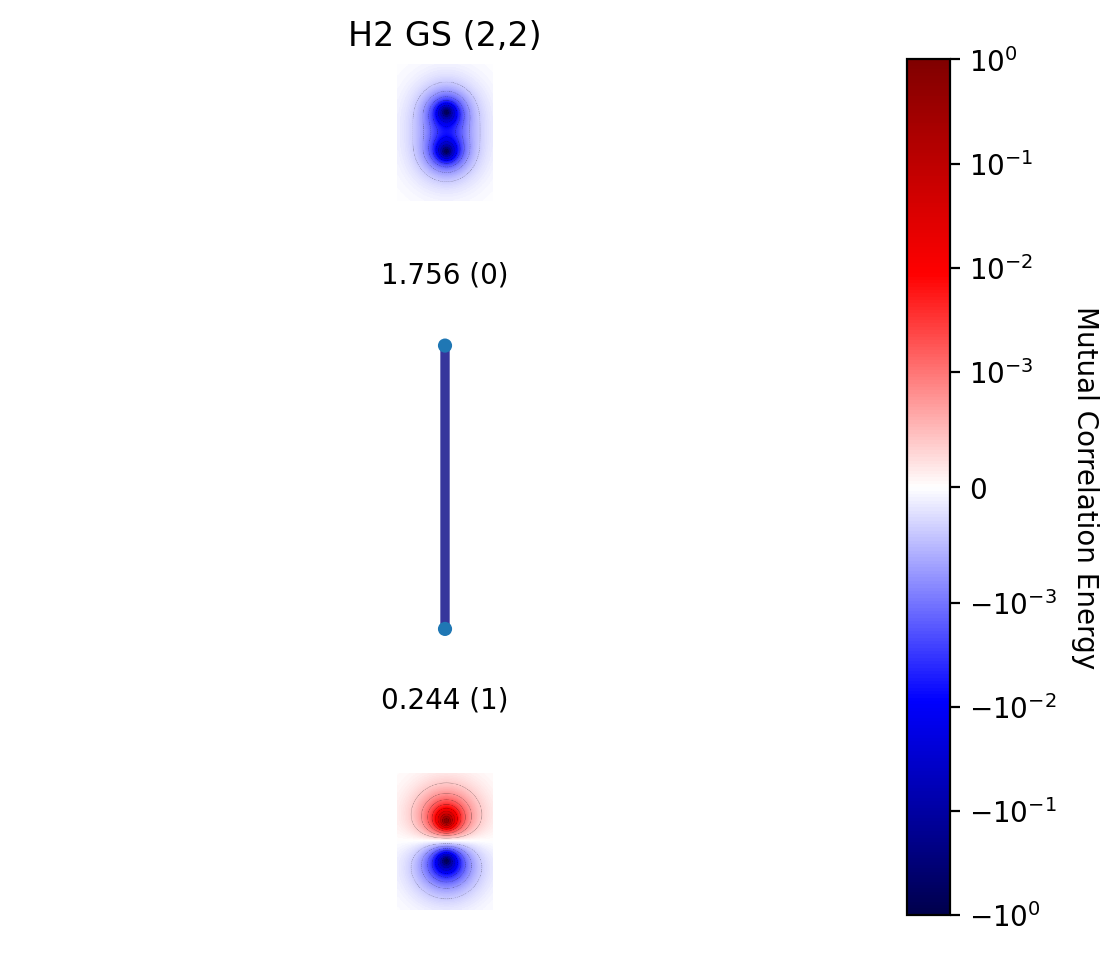

In [7]:
mutual_correlation_plot(system=system, C=ci.C[0], indices=ci.active_indices, mca=MCEmat, title="H2 GS (2,2)")

In [8]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.000 1.740
"""
system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=3,ms=1.0),active_orbitals=[0,1])(rhf) #2 electrons in 2 spin-orbitals 
ci.run()


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
Parsed 2 atoms with basis set of 10 functions.
  Max eigenvalue: 2.268e+00
  Min eigenvalue: 1.969e-01
  Condition number: 1.152e+01
  Inverse condition number: 8.683e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 10
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.969e-01
Number of electrons: 2
Number of alpha electrons: 2
Number of beta electrons: 0
Ms: 1.0
Total charge: 0
Number of basis functions: 10
Number of orthogonalized basis functions: 10
Number of auxiliary basis functions: 60
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 10
Number of auxiliary basis functio

CI(states=State(multiplicity=3, ms=1.0, nel=2, system=System(atoms=[[1, array([0., 0., 0.])], [1, array([0.        , 0.        , 3.28812346])]], basis_set=<Basis 'cc-pVDZ' with 10 basis functions>, auxiliary_basis_set=<Basis 'cc-pVTZ-JKFIT' with 60 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=2, nb=0, twice_ms=2), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=10, active_orbitals=[[0, 1]], core_orbitals=[], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=[0, 1], frozen_virtual_orbitals=None, die_if_not_converged=True, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=3, final_orbital='original', do_transition_dipole=False)

In [9]:
MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci, nat_orbs=True, nocc=2)
print(MCEmat.mutual_correlation_matrix_summary())

print(MCEmat.get_M2_matrix())
print("------------------------")
print("aa, ab, ba, bb cumulants:")
print(mcmod._spin_dependent_2cumulants(ci)[2])
print("-------------------------")
print("spin-summed 2-cumulant terms:")
c_tensor = mcmod._spin_summed_2cumulant(ci)
for i in range(0,2):
    for j in range(0,2):
        for k in range(0,2):
            for l in range(0,2):
                if abs(c_tensor[i][j][k][l]) > 1e-15:
                    print(f"p={i}, q={j}, r={k}, s={l} : {c_tensor[i][j][k][l]}")

Total Correlation Energy (Sum of the 2-Cumulant Terms):     0.0000000000

M2 Terms (|value| > 7.5e-04)
------------------------------------------
[[0. 0.]
 [0. 0.]]
------------------------
aa, ab, ba, bb cumulants:
[[[[0. 0.]
   [0. 0.]]

  [[0. 0.]
   [0. 0.]]]


 [[[0. 0.]
   [0. 0.]]

  [[0. 0.]
   [0. 0.]]]]
-------------------------
spin-summed 2-cumulant terms:


In [10]:
ints = forte2.jkbuilder.RestrictedMOIntegrals(
        system=ci.system,
        C=ci.C[0],
        orbitals=ci.active_indices,
    )
V = ints.V
print("Two electron integrals")
for i in range(0,2):
    for j in range(0,2):
        for k in range(0,2):
            for l in range(0,2):
                if abs(c_tensor[i][j][k][l]) > 1e-15:
                    print(f"p={i}, q={j}, r={k}, s={l} : {V[i][j][k][l]}")

print("")
print("2-Frag orbital correlation")
for i in range(0,2):
    for j in range(0,2):
        for k in range(0,2):
            for l in range(0,2):
                if abs(c_tensor[i][j][k][l]) > 1e-15:
                    print(f"p={i}, q={j}, r={k}, s={l} : {c_tensor[i][j][k][l]* V[i][j][k][l]}")

Two electron integrals

2-Frag orbital correlation



Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 40 x 57 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [0, 1]



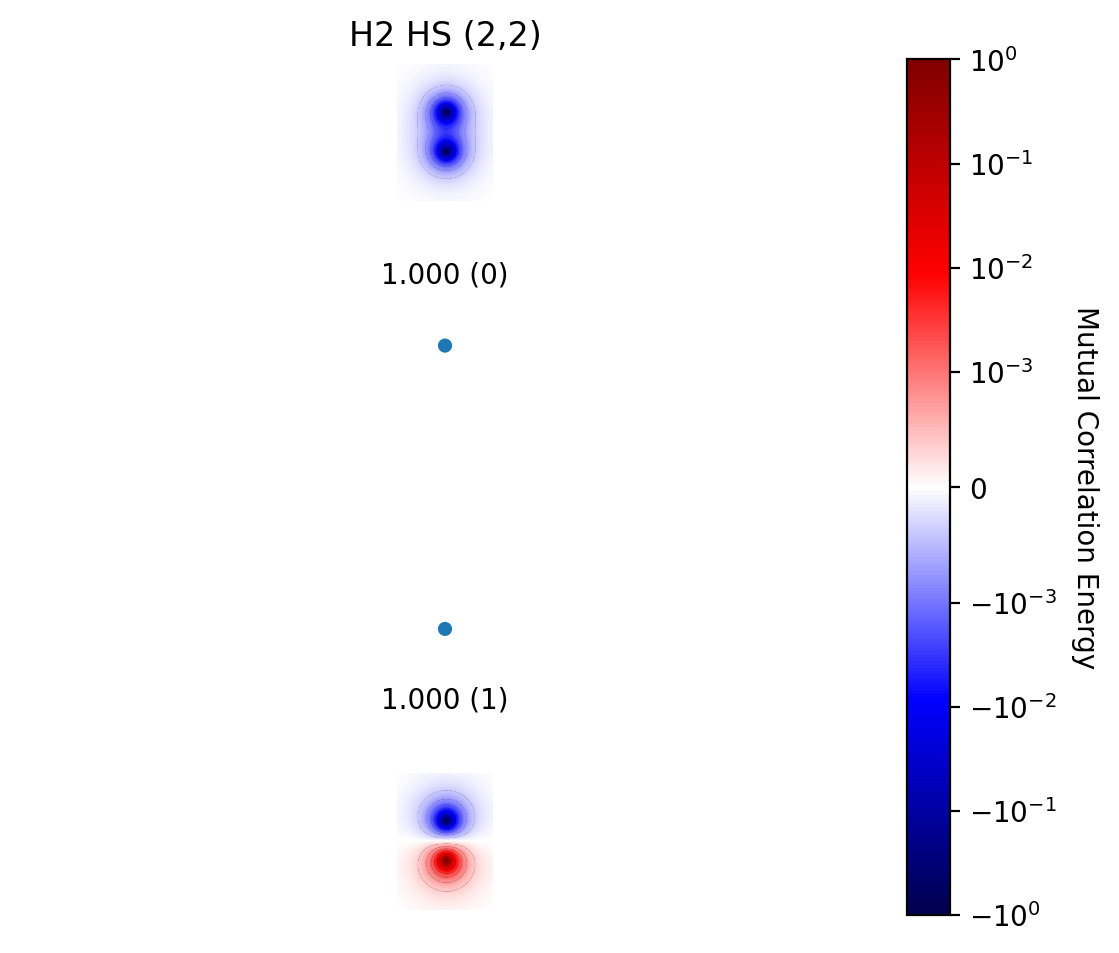

In [11]:
mutual_correlation_plot(system=system, C=ci.C[0], indices=ci.active_indices, mca=MCEmat, title="H2 HS (2,2)")